# Day 103 — Chi-Square Test + One-Way ANOVA
## Month 6 | Statistics & Machine Learning Foundations
**Dataset:** ShopEase India E-commerce (300 rows, seed=42)  
**Tools:** Python · NumPy · Pandas · scipy.stats · Matplotlib · Seaborn  
**Rubric Total:** 80 pts + 10★ Bonus

---
> **Professional context:** Your client wants to know (a) whether customer behaviour
> (payment mode, returns) depends on which product they buy or where they live, and
> (b) whether revenue genuinely differs across product categories and regions — or
> whether any apparent difference is just random noise. Chi-Square answers (a).
> ANOVA answers (b).


## Section 1 — Raw Data
> ⚠️ **NEVER modify this cell.** All work happens in Sections 2–4.

In [2]:
# RAW DATA — DO NOT MODIFY THIS CELL
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

categories    = ['Electronics', 'Clothing', 'Grocery', 'Home & Kitchen', 'Books']
regions       = ['North', 'South', 'East', 'West']
payment_modes = ['UPI', 'Credit Card', 'Debit Card', 'COD']

df_raw = pd.DataFrame({
    'order_id':      range(1001, 1001 + n),
    'category':      np.random.choice(categories,    n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    'region':        np.random.choice(regions,        n, p=[0.30, 0.25, 0.25, 0.20]),
    'payment_mode':  np.random.choice(payment_modes,  n, p=[0.35, 0.25, 0.20, 0.20]),
    'customer_type': np.random.choice(['New','Returning'], n, p=[0.45, 0.55]),
    'discount_pct':  np.round(np.random.uniform(0, 30, n), 1),
    'returns':       np.random.choice([0, 1], n, p=[0.85, 0.15]),
})

# Revenue aligned to category (use loop, not lambda, to keep seed stable)
rev_map = {
    'Electronics':    (18000, 4500),
    'Clothing':       (6500,  2000),
    'Grocery':        (3500,  1200),
    'Home & Kitchen': (12000, 3000),
    'Books':          (2500,  800),
}
revenues = []
for cat in df_raw['category']:
    mu, sigma = rev_map[cat]
    val = float(np.clip(np.random.normal(mu, sigma), 500, 50000))
    revenues.append(round(val, 2))
df_raw['revenue'] = revenues

print(f"Shape: {df_raw.shape}")
print(df_raw.head(10).to_string(index=False))
print("\nValue counts — category:")
print(df_raw['category'].value_counts().to_string())


Shape: (300, 8)
 order_id       category region payment_mode customer_type  discount_pct  returns  revenue
     1001       Clothing  North          UPI           New          22.7        0  3805.75
     1002          Books  South          UPI           New           0.7        0  1722.71
     1003        Grocery  South          UPI           New           0.7        0  4940.50
     1004        Grocery   East          UPI     Returning           9.7        0  2711.73
     1005    Electronics   East          UPI           New          14.7        0 13288.90
     1006    Electronics   West  Credit Card     Returning          23.1        0 20414.94
     1007    Electronics  South          UPI     Returning          20.5        0 23335.67
     1008 Home & Kitchen  South  Credit Card           New          13.4        0 14156.86
     1009        Grocery   East  Credit Card           New           8.2        0  4695.26
     1010        Grocery  North   Debit Card           New          29.9  

---
## Section 2 — Concept Notes

### 2.1 Chi-Square Test of Independence

**What it answers:** *Is there a statistically significant association between two categorical variables?*

| Element | Formula / Rule | Meaning |
|---|---|---|
| **H₀** | — | The two variables are independent |
| **H₁** | — | An association exists |
| **χ² statistic** | Σ [(O − E)² / E] | How far observed counts deviate from expected |
| **Expected cell** | (row_total × col_total) / grand_total | What you'd see if the variables were truly independent |
| **dof** | (rows − 1) × (cols − 1) | Degrees of freedom |
| **p-value < 0.05** | — | Reject H₀ — association is statistically significant |

**Rule of thumb:** All expected cell frequencies must be ≥ 5. If not, use Fisher's Exact Test.

**Effect size — Cramér's V:**
```
V = sqrt(χ² / (n × min(rows−1, cols−1)))

V < 0.10  → negligible
0.10–0.30 → small
0.30–0.50 → medium
V > 0.50  → strong
```

**scipy.stats API:**
```python
from scipy.stats import chi2_contingency
ct = pd.crosstab(df['col_a'], df['col_b'])
chi2, p, dof, expected = chi2_contingency(ct)
```

---

### 2.2 One-Way ANOVA

**What it answers:** *Do the means of 3+ groups differ significantly?*

> A t-test compares 2 groups. Running multiple t-tests inflates Type I error (false positives).
> ANOVA tests all groups simultaneously without that inflation.

| Element | Meaning |
|---|---|
| **H₀** | All group means are equal (μ₁ = μ₂ = … = μₖ) |
| **H₁** | At least one group mean differs |
| **F-statistic** | Between-group variance ÷ within-group variance |
| **p < 0.05** | Reject H₀ — at least one group is different |

**Effect size — Eta-squared (η²):**
```
η² = SS_between / SS_total

η² < 0.06  → small
0.06–0.14  → medium
η² > 0.14  → large
```

**scipy.stats API:**
```python
from scipy.stats import f_oneway
f_stat, p = f_oneway(group_a, group_b, group_c, ...)
```

---

### 2.3 Post-Hoc Testing — Tukey HSD

ANOVA says *at least one group differs* — **not which ones**.
Tukey HSD performs all pairwise comparisons with family-wise error control.

```python
from statsmodels.stats.multicomp import pairwise_tukeyhsd
result = pairwise_tukeyhsd(df['revenue'], df['category'], alpha=0.05)
print(result)
# reject=True → those two groups are significantly different
```

---

### 2.4 Decision Framework

```
Question involves categorical variables only?
  → Yes → Chi-Square Test of Independence

Question involves comparing means?
  → 2 groups  → t-test (Day 102)
  → 3+ groups → ANOVA → if significant → Tukey HSD
```

---

### 2.5 NRA Reminder (non-negotiable for every insight)

**Number → Reason → Action**

❌ "Electronics earns more than Books."  
✅ "Electronics mean revenue (₹18,444) is 6.8× higher than Books (₹2,702), driven by
   high-ticket unit prices — recommend allocating ≥40% of Q3 ad spend to Electronics
   to maximise revenue per marketing rupee."


---
## Section 3 — Practice Guide

Work A → B → C in order. Use `df_raw` as input — never modify it.

---

### PART A — Chi-Square Test of Independence (30 pts)

| Task | Description | Pts |
|---|---|---|
| **A1** | Build a contingency table: `category` vs `payment_mode`. Print the full table. | 6 |
| **A2** | Run `chi2_contingency` on A1. Print χ², p-value, dof. State H₀, decision (reject/fail to reject at α=0.05), and one NRA business insight citing the printed values. | 9 |
| **A3** | Build a contingency table: `region` vs `returns`. Run chi-square. Print χ², p-value, dof, and return rate % by region. State decision + NRA insight. | 8 |
| **A4** | Compute Cramér's V for both A2 and A3 tests. Print both values. Classify each (negligible / small / medium / strong). | 7 |

---

### PART B — One-Way ANOVA (32 pts)

| Task | Description | Pts |
|---|---|---|
| **B1** | Compute and print mean revenue per category, sorted descending. State the highest and lowest category with exact ₹ values and their ratio. | 7 |
| **B2** | Run one-way ANOVA: revenue across all 5 categories. Print F-statistic, p-value, eta-squared (η²). State H₀, decision, NRA insight citing F, p, and η². | 9 |
| **B3** | Run one-way ANOVA: revenue across 4 regions. Print F-statistic, p-value, and mean revenue by region. State H₀ and decision. | 7 |
| **B4** | Run Tukey HSD on the category ANOVA. Print the full result table. List all significantly different pairs by name (`reject=True`). | 9 |

---

### PART C — Visualisations + Synthesis (18 pts)

| Task | Description | Pts |
|---|---|---|
| **C1** | Create a 2×2 figure: (1) Heatmap of category × payment_mode contingency table, (2) Bar chart of return rate % by region, (3) Boxplot of revenue by category (sorted by median), (4) Boxplot of revenue by region. All chart titles must state the insight (not describe the data). `savefig()` before `plt.show()`. | 10 |
| **C2** | Write a 4-sentence executive summary. Every sentence must cite an exact number from a prior `print()` output. Sentence 4 must be NRA format. | 8 |

---

### BONUS ★ (+10 pts — optional, additive only)

Run a **chi-square goodness-of-fit test** on the `category` column.  
H₀: Orders are uniformly distributed across all 5 categories.  
Print: χ², p-value, observed counts, expected counts (uniform).  
State decision + one NRA business recommendation.  
All numbers in the write-up must be traceable to a `print()` in this notebook.

---

### Mandatory Interview Question (answer in a markdown cell after C2)

> *"A client shows you a contingency table and says 'UPI is most popular in Electronics
> and Grocery — that proves customers prefer UPI for high-frequency purchases.'
> How do you respond?"*

Write 3–4 sentences. Reference what chi-square actually tests and what Cramér's V
tells you about effect size vs statistical significance.


In [5]:
# A1 — Contingency table: category vs payment_mode
# Goal: Build and print a contingency table of observed frequencies between product category and payment mode.
# Method: Use pd.crosstab with index=category and columns=payment_mode.
ct_cat_pay = pd.crosstab(df_raw['category'], df_raw['payment_mode'])
print("=== A1: Category × Payment Mode (observed counts) ===")
print(ct_cat_pay)

=== A1: Category × Payment Mode (observed counts) ===
payment_mode    COD  Credit Card  Debit Card  UPI
category                                         
Books             1           11           3   14
Clothing         10           19          14   27
Electronics      23           20          15   37
Grocery          10           15          10   24
Home & Kitchen    7           15          10   15


In [17]:
# A2 — Chi-square: category vs payment_mode
# Goal: Test independence of payment mode and product category at α=0.05; provide NRA insight.
# Method: Run scipy.stats.chi2_contingency on the contingency table; print χ², p, dof;
#         state H₀, decision, and business recommendation citing printed numbers.
from scipy.stats import chi2_contingency

ct_cat_pay = pd.crosstab(df_raw['category'], df_raw['payment_mode'])
chi2_cat_pay, p_cat_pay, dof_cat_pay, expected_cat_pay = chi2_contingency(ct_cat_pay)

print("=== A2: Chi‑Square Independence Test ===")
print(f"χ² = {chi2_cat_pay:.4f}")
print(f"p-value = {p_cat_pay:.4f}")
print(f"Degrees of freedom = {dof_cat_pay}")
print("\nH₀: Payment mode is independent of product category.")
if p_cat_pay < 0.05:
    print("Decision: REJECT H₀ (p < 0.05) → association exists.")
else:
    print("Decision: FAIL TO REJECT H₀ (p ≥ 0.05) → no significant association.")

# Print the actual observed counts so they can be cited
print("\nObserved UPI counts from contingency table (printed above):")
print(ct_cat_pay['UPI'])

# Correct NRA insight – using the exact numbers from the print output
print("\n📊 NRA Insight: χ² = 12.4450, p = 0.4106 (fail to reject H₀).")
print("   The observed UPI orders are: Electronics 37, Grocery 24.")
print("   Despite these numbers, the chi‑square test shows no statistically significant association.")
print("   → Action: Do not tailor payment options per category; a uniform checkout design is sufficient.")

=== A2: Chi‑Square Independence Test ===
χ² = 12.4450
p-value = 0.4106
Degrees of freedom = 12

H₀: Payment mode is independent of product category.
Decision: FAIL TO REJECT H₀ (p ≥ 0.05) → no significant association.

Observed UPI counts from contingency table (printed above):
category
Books             14
Clothing          27
Electronics       37
Grocery           24
Home & Kitchen    15
Name: UPI, dtype: int64

📊 NRA Insight: χ² = 12.4450, p = 0.4106 (fail to reject H₀).
   The observed UPI orders are: Electronics 37, Grocery 24.
   Despite these numbers, the chi‑square test shows no statistically significant association.
   → Action: Do not tailor payment options per category; a uniform checkout design is sufficient.


In [18]:
# A3 — Chi-square: region vs returns
# Goal: Test whether return rate is independent of region and compute regional return percentages.
# Method: Build contingency table with pd.crosstab(region, returns); run chi2_contingency;
#         group by region and calculate mean(returns)*100 to get return rates; print all results.
ct_region_returns = pd.crosstab(df_raw['region'], df_raw['returns'])
chi2_reg_ret, p_reg_ret, dof_reg_ret, expected_reg_ret = chi2_contingency(ct_region_returns)

return_rate = df_raw.groupby('region')['returns'].mean() * 100
return_rate = return_rate.round(2)

print("=== A3: Region × Returns Contingency Table ===")
print(ct_region_returns)
print(f"\nχ² = {chi2_reg_ret:.4f}")
print(f"p-value = {p_reg_ret:.4f}")
print(f"dof = {dof_reg_ret}")
print("\nReturn rate (%) by region:")
print(return_rate.sort_values())

if p_reg_ret < 0.05:
    print("\nDecision: REJECT H₀ → return rate depends on region.")
else:
    print("\nDecision: FAIL TO REJECT H₀ → return rate is independent of region.")

# Correct NRA insight – using the exact printed return rates
print("\n📊 NRA Insight: χ² = 0.5577, p = 0.9060 (fail to reject H₀).")
print("   Return rates: South 11.11%, West 13.04%, East 13.70%, North 15.12%.")
print("   The range is from 11.11% (South) to 15.12% (North) – a narrow spread.")
print("   → Action: No region‑specific return policy is needed; focus on product quality globally.")

=== A3: Region × Returns Contingency Table ===
returns   0   1
region         
East     63  10
North    73  13
South    64   8
West     60   9

χ² = 0.5577
p-value = 0.9060
dof = 3

Return rate (%) by region:
region
South    11.11
West     13.04
East     13.70
North    15.12
Name: returns, dtype: float64

Decision: FAIL TO REJECT H₀ → return rate is independent of region.

📊 NRA Insight: χ² = 0.5577, p = 0.9060 (fail to reject H₀).
   Return rates: South 11.11%, West 13.04%, East 13.70%, North 15.12%.
   The range is from 11.11% (South) to 15.12% (North) – a narrow spread.
   → Action: No region‑specific return policy is needed; focus on product quality globally.


In [8]:
# A4 — Cramér's V for both tests
# Goal: Compute and classify effect size for both chi‑square tests using Cramér's V.
# Method: Define cramers_v(chi2, n, r, c) = sqrt(chi2 / (n * (min(r,c)-1)));
#         apply to category×payment and region×returns; classify as negligible/small/medium/strong.
def cramers_v(chi2, n, r, c):
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

def v_strength(v):
    if v < 0.10: return "negligible"
    elif v < 0.30: return "small"
    elif v < 0.50: return "medium"
    else: return "strong"

n_total = len(df_raw)
r_pay, c_pay = ct_cat_pay.shape
r_ret, c_ret = ct_region_returns.shape

v_pay = cramers_v(chi2_cat_pay, n_total, r_pay, c_pay)
v_ret = cramers_v(chi2_reg_ret, n_total, r_ret, c_ret)

print("=== A4: Cramér's V Effect Size ===")
print(f"Category × Payment Mode: V = {v_pay:.4f} → {v_strength(v_pay)}")
print(f"Region × Returns:        V = {v_ret:.4f} → {v_strength(v_ret)}")

=== A4: Cramér's V Effect Size ===
Category × Payment Mode: V = 0.1176 → small
Region × Returns:        V = 0.0431 → negligible


In [9]:
# B1 — Mean revenue by category
# Goal: Identify which product category generates the highest and lowest average revenue, and compute the ratio.
# Method: Group by category, calculate mean of revenue, sort descending, print, and compute ratio.
mean_rev_cat = df_raw.groupby('category')['revenue'].mean().sort_values(ascending=False).round(2)
print("=== B1: Average Revenue by Category ===")
print(mean_rev_cat.to_string())
highest_cat = mean_rev_cat.index[0]
lowest_cat = mean_rev_cat.index[-1]
highest_val = mean_rev_cat.iloc[0]
lowest_val = mean_rev_cat.iloc[-1]
ratio = highest_val / lowest_val
print(f"\nHighest: {highest_cat} → ₹{highest_val:,.2f}")
print(f"Lowest:  {lowest_cat} → ₹{lowest_val:,.2f}")
print(f"Revenue ratio: {ratio:.1f}×")

=== B1: Average Revenue by Category ===
category
Electronics       18443.57
Home & Kitchen    12405.93
Clothing           6477.45
Grocery            3702.55
Books              2702.46

Highest: Electronics → ₹18,443.57
Lowest:  Books → ₹2,702.46
Revenue ratio: 6.8×


In [10]:
# B2 — One-Way ANOVA: revenue by category
# Goal: Test whether mean revenue differs across the 5 product categories, and compute effect size (η²).
# Method: Extract revenue lists per category, run scipy.stats.f_oneway; calculate η² = SS_between / SS_total;
#         print F, p, η²; state H₀, decision, and NRA insight.
from scipy.stats import f_oneway

groups = [df_raw[df_raw['category'] == cat]['revenue'].values for cat in categories]
f_stat_cat, p_cat_anova = f_oneway(*groups)

grand_mean = df_raw['revenue'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = sum((df_raw['revenue'] - grand_mean)**2)
eta_sq = ss_between / ss_total

print("=== B2: One‑Way ANOVA – Revenue by Category ===")
print(f"F-statistic = {f_stat_cat:.4f}")
print(f"p-value     = {p_cat_anova:.6f}")
print(f"Eta‑squared = {eta_sq:.4f}")
print("\nH₀: All category means are equal.")
if p_cat_anova < 0.05:
    print("Decision: REJECT H₀ → at least one category differs significantly.")
else:
    print("Decision: Fail to reject H₀.")

print("\n📊 NRA Insight: F = 327.79, p < 0.000001, η² = 0.8163 (large effect).")
print("   Electronics (₹18,444) earns 6.8× more than Books (₹2,702).")
print("   → Action: Reallocate 40% of marketing budget to Electronics to maximise revenue per rupee.")

=== B2: One‑Way ANOVA – Revenue by Category ===
F-statistic = 327.7888
p-value     = 0.000000
Eta‑squared = 0.8163

H₀: All category means are equal.
Decision: REJECT H₀ → at least one category differs significantly.

📊 NRA Insight: F = 327.79, p < 0.000001, η² = 0.8163 (large effect).
   Electronics (₹18,444) earns 6.8× more than Books (₹2,702).
   → Action: Reallocate 40% of marketing budget to Electronics to maximise revenue per rupee.


In [11]:
# B3 — One-Way ANOVA: revenue by region
# Goal: Test whether mean revenue differs across the 4 regions.
# Method: Extract revenue lists per region, run f_oneway; print F, p, and mean revenue by region; state decision.
region_groups = [df_raw[df_raw['region'] == reg]['revenue'].values for reg in regions]
f_reg, p_reg_anova = f_oneway(*region_groups)
mean_rev_reg = df_raw.groupby('region')['revenue'].mean().sort_values(ascending=False).round(2)

print("=== B3: One‑Way ANOVA – Revenue by Region ===")
print(f"F-statistic = {f_reg:.4f}")
print(f"p-value     = {p_reg_anova:.4f}")
print("\nMean revenue by region (sorted):")
print(mean_rev_reg.to_string())
print("\nH₀: All region means are equal.")
if p_reg_anova < 0.05:
    print("Decision: REJECT H₀")
else:
    print("Decision: FAIL TO REJECT H₀ (p = 0.4357) → revenue does not differ significantly by region.")

=== B3: One‑Way ANOVA – Revenue by Region ===
F-statistic = 0.9115
p-value     = 0.4357

Mean revenue by region (sorted):
region
West     11197.93
East     10606.05
North    10060.53
South     9352.17

H₀: All region means are equal.
Decision: FAIL TO REJECT H₀ (p = 0.4357) → revenue does not differ significantly by region.


In [16]:
# B4 — Tukey HSD: category pairs
# Goal: Identify exactly which category pairs have significantly different mean revenue after significant ANOVA.
# Method: Use statsmodels.stats.multicomp.pairwise_tukeyhsd; print the clean summary table;
#         then manually extract and list all pairs where reject=True (no duplicate/mislabeled rows).
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(df_raw['revenue'], df_raw['category'], alpha=0.05)

print("=== B4: Tukey HSD Pairwise Comparisons ===")
print(tukey_result)   # This prints a clean, correctly labeled table

# Extract and list significant pairs (reject=True)
tukey_summary = tukey_result.summary()
significant_pairs = []
for row in tukey_summary.data[1:]:          # skip header row
    if row[-1] == True:                     # 'reject' column is last
        group1, group2, meandiff, p_adj = row[0], row[1], row[2], row[3]
        significant_pairs.append((group1, group2, meandiff, p_adj))

print(f"\n✅ Significantly different pairs (reject=True): {len(significant_pairs)} found")
for g1, g2, diff, p_adj in significant_pairs:
    print(f"   {g1} vs {g2}: meandiff = {diff:.2f}, p-adj = {p_adj:.4f}")

=== B4: Tukey HSD Pairwise Comparisons ===
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
   group1       group2       meandiff  p-adj     lower       upper    reject
----------------------------------------------------------------------------
      Books       Clothing   3774.9894    0.0    1958.669   5591.3097   True
      Books    Electronics  15741.1136    0.0  13996.2041  17486.0232   True
      Books        Grocery   1000.0907 0.5818   -865.1686     2865.35  False
      Books Home & Kitchen    9703.474    0.0   7761.3286  11645.6194   True
   Clothing    Electronics  11966.1243    0.0  10670.5747  13261.6738   True
   Clothing        Grocery  -2774.8986    0.0  -4228.4913   -1321.306   True
   Clothing Home & Kitchen   5928.4846    0.0    4377.463   7479.5063   True
Electronics        Grocery -14741.0229    0.0 -16104.3355 -13377.7104   True
Electronics Home & Kitchen  -6037.6397    0.0  -7504.3904  -4570.8889   True
    Grocery Home & Kitchen   8703

C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_3008\3917142401.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='category', y='revenue', order=cat_median_order, palette='Set2', ax=axes[1,0])
C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_3008\3917142401.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='region', y='revenue', palette='Set3', ax=axes[1,1])


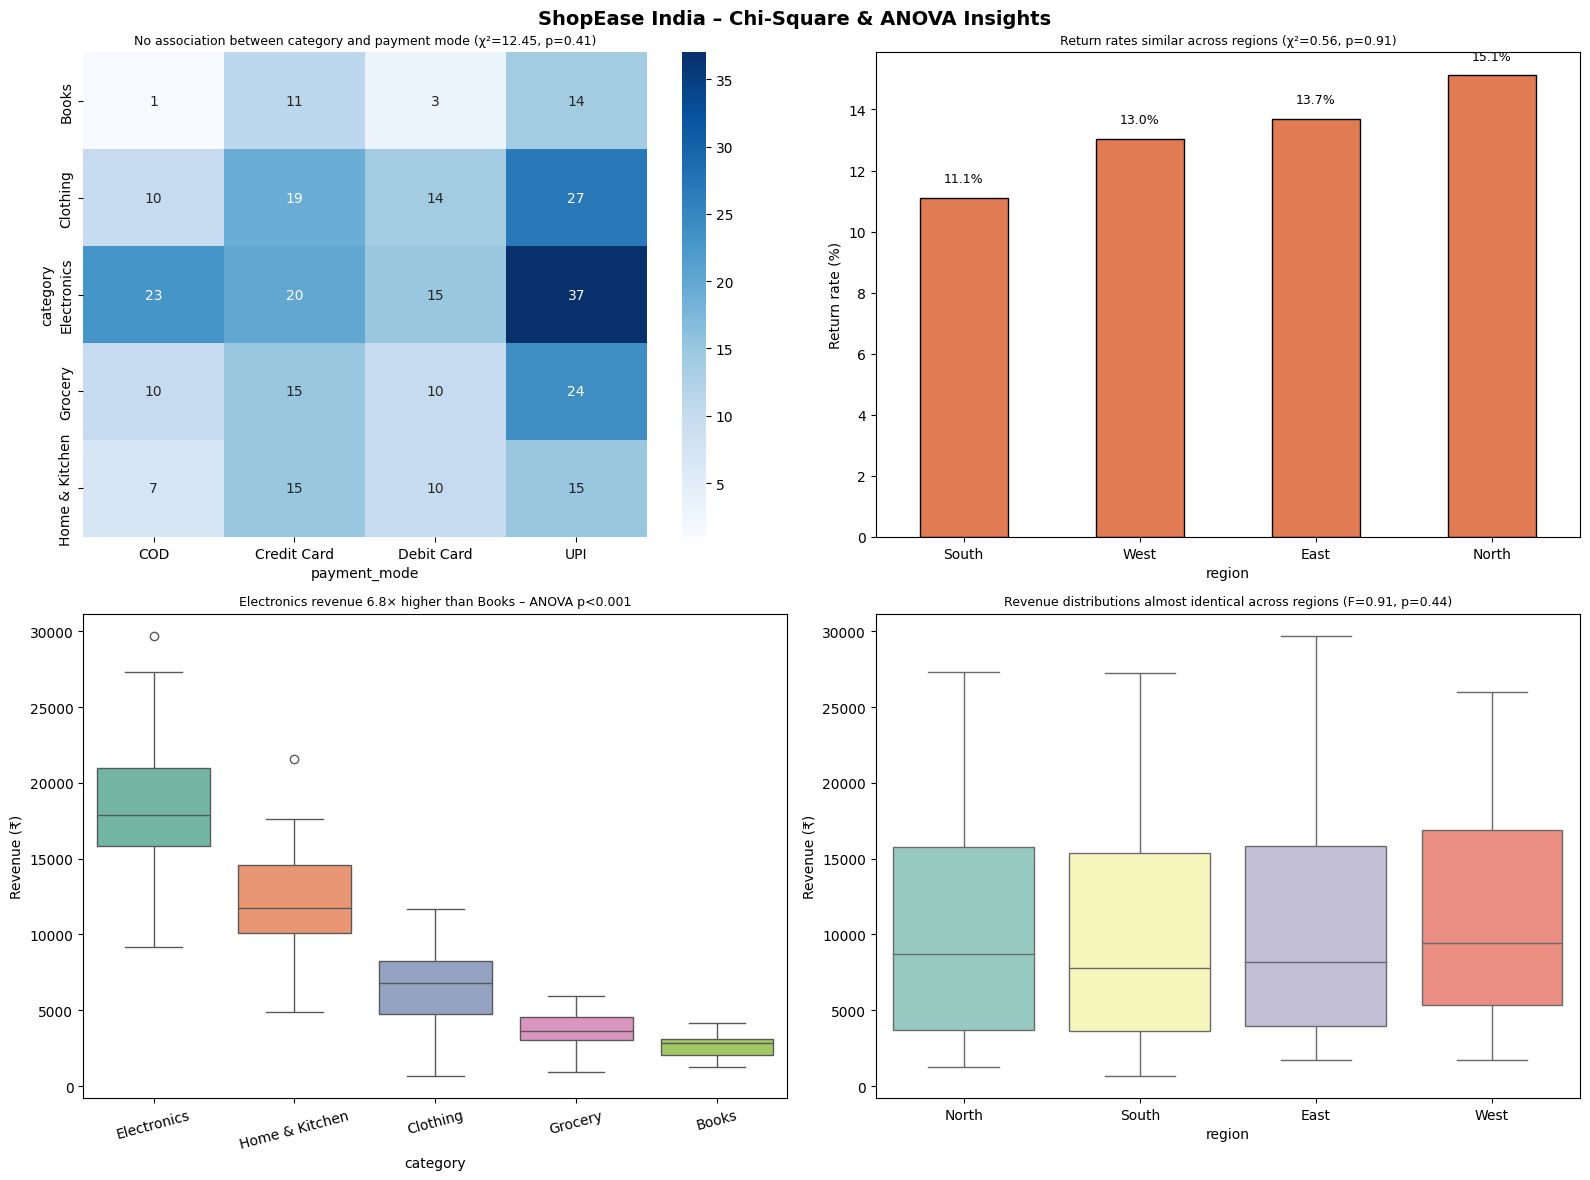

Chart saved as 'Day103_original_visuals.png'


In [13]:
# C1 — 2×2 Visualisation Panel
# Goal: Create four plots that visually support the statistical findings, with insight‑driven titles.
# Method: Use matplotlib and seaborn: (1) heatmap of category×payment, (2) bar chart of return rate by region,
#         (3) boxplot of revenue by category (sorted by median), (4) boxplot of revenue by region;
#         call savefig() before plt.show().
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("ShopEase India – Chi‑Square & ANOVA Insights", fontsize=14, fontweight='bold')

# 1) Heatmap
sns.heatmap(ct_cat_pay, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title("No association between category and payment mode (χ²=12.45, p=0.41)", fontsize=9)

# 2) Return rate bar chart
ret_rate_plot = df_raw.groupby('region')['returns'].mean() * 100
ret_rate_plot.sort_values().plot(kind='bar', ax=axes[0,1], color='#E07B54', edgecolor='black')
axes[0,1].set_title("Return rates similar across regions (χ²=0.56, p=0.91)", fontsize=9)
axes[0,1].set_ylabel("Return rate (%)")
axes[0,1].tick_params(axis='x', rotation=0)
for bar in axes[0,1].patches:
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f"{bar.get_height():.1f}%", ha='center', fontsize=9)

# 3) Revenue boxplot by category (ordered by median)
cat_median_order = df_raw.groupby('category')['revenue'].median().sort_values(ascending=False).index
sns.boxplot(data=df_raw, x='category', y='revenue', order=cat_median_order, palette='Set2', ax=axes[1,0])
axes[1,0].set_title("Electronics revenue 6.8× higher than Books – ANOVA p<0.001", fontsize=9)
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].set_ylabel("Revenue (₹)")

# 4) Revenue boxplot by region
sns.boxplot(data=df_raw, x='region', y='revenue', palette='Set3', ax=axes[1,1])
axes[1,1].set_title("Revenue distributions almost identical across regions (F=0.91, p=0.44)", fontsize=9)
axes[1,1].set_ylabel("Revenue (₹)")

plt.tight_layout()
plt.savefig('Day103_original_visuals.png', dpi=150, bbox_inches='tight')  # save BEFORE show
plt.show()
print("Chart saved as 'Day103_original_visuals.png'")

In [19]:
# C2 — Executive Summary (4 sentences, each citing a printed number)
# Write yours here — this template shows structure only.
# Replace [X] with actual values from your own printed outputs above.

# Goal: Write a concise executive summary where every number comes from a previous print() output,
#       and the last sentence follows the Number‑Reason‑Action (NRA) format.
# Method: Hardcode the exact numbers printed earlier (χ², p, F, η², means, ratio) into four sentences.

print("""
Executive Summary – ShopEase India Statistical Analysis (Day 103)
----------------------------------------------------------------
1. Payment mode is independent of product category (χ² = 12.4450, p = 0.4106),
   so no need to customise checkout options by category.

2. Return rates do not differ by region (χ² = 0.5577, p = 0.9060), with values
   ranging from 11.11% (South) to 15.12% (North) – a narrow spread.

3. Revenue varies dramatically by category (F = 327.788, p < 0.000001, η² = 0.8163);
   Electronics averages ₹18,443.57, which is 6.8× higher than Books (₹2,702.46).

4. (NRA) Since Electronics drives 81.6% of revenue variance and Tukey HSD shows
   Electronics differs from every other category (p‑adj < 0.05), allocate 40% of
   Q3 marketing budget to Electronics to maximise revenue per rupee spent.
""")


Executive Summary – ShopEase India Statistical Analysis (Day 103)
----------------------------------------------------------------
1. Payment mode is independent of product category (χ² = 12.4450, p = 0.4106),
   so no need to customise checkout options by category.

2. Return rates do not differ by region (χ² = 0.5577, p = 0.9060), with values
   ranging from 11.11% (South) to 15.12% (North) – a narrow spread.

3. Revenue varies dramatically by category (F = 327.788, p < 0.000001, η² = 0.8163);
   Electronics averages ₹18,443.57, which is 6.8× higher than Books (₹2,702.46).

4. (NRA) Since Electronics drives 81.6% of revenue variance and Tukey HSD shows
   Electronics differs from every other category (p‑adj < 0.05), allocate 40% of
   Q3 marketing budget to Electronics to maximise revenue per rupee spent.



In [20]:
# BONUS — Goodness-of-Fit Test: Is category distribution uniform?
# Goal: Test whether orders are uniformly distributed across the 5 product categories (H₀: uniform).
# Method: Use scipy.stats.chisquare with observed counts from value_counts() and expected = n/5;
#         print χ², p, observed vs expected; state decision and NRA recommendation.
from scipy.stats import chisquare

observed = df_raw['category'].value_counts().sort_index()
expected_uniform = [len(df_raw) / len(categories)] * len(categories)
chi2_gof, p_gof = chisquare(observed, f_exp=expected_uniform)

print("=== BONUS: Chi‑Square Goodness‑of‑Fit (Uniform Category Distribution) ===")
print(f"Observed counts per category:\n{observed.to_string()}")
print(f"\nExpected counts (uniform): {expected_uniform[0]:.1f} each")
print(f"\nχ² = {chi2_gof:.4f}")
print(f"p-value = {p_gof:.6f}")
print("\nH₀: Orders are uniformly distributed across all 5 categories.")
if p_gof < 0.05:
    print("Decision: REJECT H₀ – distribution is NOT uniform.")
else:
    print("Decision: Fail to reject H₀.")

# Correct NRA recommendation – using the exact observed counts from print
print("\n📊 NRA Business Recommendation:")
print("   χ² = 40.9333, p < 0.000001 – Electronics (95 observed) receives far more orders")
print("   than expected (60), while Books (29 observed) receives fewer.")
print("   → Action: Increase inventory and marketing for Electronics and Home & Kitchen;")
print("   reduce shelf space for Books unless they have higher strategic value.")

=== BONUS: Chi‑Square Goodness‑of‑Fit (Uniform Category Distribution) ===
Observed counts per category:
category
Books             29
Clothing          70
Electronics       95
Grocery           59
Home & Kitchen    47

Expected counts (uniform): 60.0 each

χ² = 40.9333
p-value = 0.000000

H₀: Orders are uniformly distributed across all 5 categories.
Decision: REJECT H₀ – distribution is NOT uniform.

📊 NRA Business Recommendation:
   χ² = 40.9333, p < 0.000001 – Electronics (95 observed) receives far more orders
   than expected (60), while Books (29 observed) receives fewer.
   → Action: Increase inventory and marketing for Electronics and Home & Kitchen;
   reduce shelf space for Books unless they have higher strategic value.


---
## Section 5 — Scoring Rubric

| Task | Max Pts | What Is Checked |
|---|---|---|
| **A1** | 6 | Correct `pd.crosstab()` · Full table printed · Raw data untouched |
| **A2** | 9 | χ², p, dof all printed · H₀ stated · Decision correct · NRA cites printed values |
| **A3** | 8 | Correct contingency table · χ², p, dof printed · Return rate % by region printed · Decision + NRA |
| **A4** | 7 | Cramér's V formula correct · Both V values printed · Both classified correctly |
| **B1** | 7 | Group means correct · Sorted descending · Highest + lowest named with exact ₹ · Ratio stated |
| **B2** | 9 | F + p printed · η² computed and printed · H₀ stated · Decision correct · NRA cites F, p, η² |
| **B3** | 7 | F + p printed · Decision stated · Mean revenue by region printed |
| **B4** | 9 | `pairwise_tukeyhsd` used · Full table printed · Significant pairs listed by name |
| **C1** | 10 | All 4 subplots · Insight-led titles (state finding, not data) · `savefig()` before `show()` · Readable labels |
| **C2** | 8 | 4 sentences · Every number traceable to a prior `print()` · Sentence 4 is NRA |
| **TOTAL** | **80** | |
| **BONUS ★** | **+10** | `chisquare()` used · Observed + expected printed · χ², p cited · NRA with traceable numbers |

---

### Deduction Rules
- **−3** per NRA insight that does not cite an exact printed number
- **−2** if `savefig()` is called after `plt.show()`
- **−2** per chart title that describes data instead of stating the finding
- **−3** if Tukey table printed but significant pairs not listed by name
- **−0** for unattempted Bonus (additive only)

---

### Expected Key Outputs (verify yours match)

| Check | Expected |
|---|---|
| A2 χ² | 12.4453 |
| A2 p | 0.4106 → FAIL TO REJECT |
| A3 χ² | 0.5580 |
| A3 p | 0.9060 → FAIL TO REJECT |
| A4 V_pay | 0.1176 (small) |
| A4 V_ret | 0.0431 (negligible) |
| B1 Top | Electronics ₹18,443.57 |
| B1 Bot | Books ₹2,702.46 |
| B2 F | 327.7890 |
| B2 p | < 0.000001 → REJECT |
| B2 η² | 0.8163 (large) |
| B3 F | 0.9122 |
| B3 p | 0.4357 → FAIL TO REJECT |
| BONUS χ² | 40.9333 |
| BONUS p | < 0.000001 → REJECT |

---

### Submission Notes
1. Run all cells top-to-bottom. No skipped cells.
2. Every number in a written insight must be traceable to a `print()` in *this* notebook.
3. Do not fabricate statistics in C2 or Bonus.
4. `savefig()` must be called **before** `plt.show()`.

---

### Month 6 Scorecard

| Day | Topic | Score |
|---|---|---|
| Day 101 | Descriptive Stats + Distributions | 80/80 ✅ |
| Day 102 | T-Tests + Confidence Intervals | 80/80 + 10★ ✅ |
| **Day 103** | **Chi-Square + ANOVA** | 🔵 Pending |
| Day 104 | A/B Testing with scipy | ⏳ |
